# Common errors and what they mean

`spatialdata-plot` validates its inputs up front and fails with an actionable message rather than deep
inside matplotlib or datashader. This notebook collects the errors you are most likely to hit, shows
what triggers each, and gives the one-line fix. Each cell deliberately raises and catches the error so
you can read the exact message.

We use the synthetic `blobs` dataset throughout.

## Setup

In [1]:
import numpy as np  # noqa: F401
import spatialdata as sd
import spatialdata_plot  # noqa: F401  # registers the .pl accessor
from matplotlib.colors import Normalize
from spatialdata_plot import PercentileNormalize

sdata = sd.datasets.blobs()
sdata

SpatialData object
├── Images
│     ├── 'blobs_image': DataArray[cyx] (3, 512, 512)
│     └── 'blobs_multiscale_image': DataTree[cyx] (3, 512, 512), (3, 256, 256), (3, 128, 128)
├── Labels
│     ├── 'blobs_labels': DataArray[yx] (512, 512)
│     └── 'blobs_multiscale_labels': DataTree[yx] (512, 512), (256, 256), (128, 128)
├── Points
│     └── 'blobs_points': DataFrame with shape: (<Delayed>, 4) (2D points)
├── Shapes
│     ├── 'blobs_circles': GeoDataFrame shape: (5, 2) (2D shapes)
│     ├── 'blobs_multipolygons': GeoDataFrame shape: (2, 1) (2D shapes)
│     └── 'blobs_polygons': GeoDataFrame shape: (5, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (26, 3)
with coordinate systems:
    ▸ 'global', with elements:
        blobs_image (Images), blobs_multiscale_image (Images), blobs_labels (Labels), blobs_multiscale_labels (Labels), blobs_points (Points), blobs_circles (Shapes), blobs_multipolygons (Shapes), blobs_polygons (Shapes)

## 1. Element not found

A typo in the element name raises a `KeyError` naming the element it looked for. Check
`sdata` for the exact key.

In [2]:
try:
    sdata.pl.render_shapes("blobs_circle").pl.show()  # missing trailing 's'
except KeyError as e:
    print("KeyError:", e)

KeyError: "Could not find element with name 'blobs_circle'"


## 2. Colouring by a column with no annotating table

To colour an element by a column, that column must live on the element or on a table annotating it.
Passing a name that is neither a valid colour nor an available column raises, naming the element and
the column.

In [3]:
try:
    sdata.pl.render_shapes("blobs_circles", color="gene_x").pl.show()
except KeyError as e:
    print("KeyError:", e)

KeyError: "Element 'blobs_circles' has no annotating tables. Cannot use column 'gene_x' for coloring. Please ensure the element is annotated by at least one table."


## 3. Invalid image channel

Selecting a channel that does not exist raises a `ValueError` that lists the valid channels — helpful
when you are unsure how a multichannel image is indexed (see the *Multichannel & fluorescence images*
tutorial).

In [4]:
try:
    sdata.pl.render_images("blobs_image", channel="DAPI").pl.show()
except ValueError as e:
    print("ValueError:", e)

ValueError: Invalid channel(s): DAPI. Valid choices are: [0 1 2]


## 4. A per-channel `norm` list of the wrong length

When you pass a list of norms for an image, its length must match the number of channels you are
rendering (see the *Normalization and contrast* tutorial).

In [5]:
try:
    sdata.pl.render_images("blobs_image", channel=[0, 1, 2], norm=[Normalize()] * 2).pl.show()
except ValueError as e:
    print("ValueError:", e)

ValueError: Length of 'norm' list (2) must match the number of channels (3).


## 5. `grayscale` needs exactly three channels

`grayscale=True` collapses a three-channel selection into one intensity, so it requires exactly three
channels.

ValueError: grayscale=True requires exactly 3 channels, got 1. Select 3 channels via the 'channel' parameter.


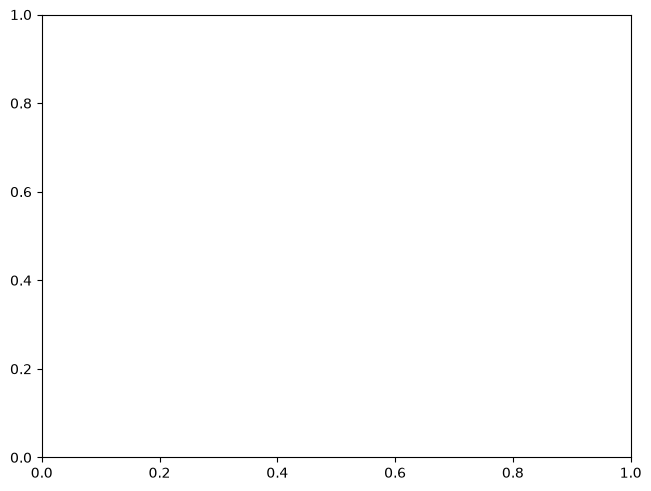

In [6]:
try:
    sdata.pl.render_images("blobs_image", channel=[0], grayscale=True).pl.show()
except ValueError as e:
    print("ValueError:", e)

## 6. Invalid `PercentileNormalize` bounds

Percentile bounds are validated at construction time: they must satisfy `0 <= pmin < pmax <= 100`.

In [7]:
for bad in [(50, 50), (90, 10), (-1, 50), (0, 101)]:
    try:
        PercentileNormalize(*bad)
    except ValueError as e:
        print(f"PercentileNormalize{bad} -> {e}")

PercentileNormalize(50, 50) -> Require 0 <= pmin < pmax <= 100, got pmin=50, pmax=50.
PercentileNormalize(90, 10) -> Require 0 <= pmin < pmax <= 100, got pmin=90, pmax=10.
PercentileNormalize(-1, 50) -> Require 0 <= pmin < pmax <= 100, got pmin=-1, pmax=50.
PercentileNormalize(0, 101) -> Require 0 <= pmin < pmax <= 100, got pmin=0, pmax=101.


## Summary

`spatialdata-plot` fails fast with messages that name the offending element, column, channel, or
bound:

- **Element not found** — check the key in `sdata`.
- **No column to colour by** — put the value on the element or its annotating table.
- **Invalid channel** — the message lists the valid channels.
- **Wrong-length `norm` list** — one norm per rendered channel.
- **`grayscale` needs three channels** — select exactly three.
- **Invalid percentile bounds** — `0 <= pmin < pmax <= 100`.

When a plot fails, read the message first — it usually names the fix.

## For reproducibility

In [8]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import warnings
import spatialdata_plot

%load_ext watermark
# fmt: on

%watermark -v -m -p spatialdata,spatialdata_plot,matplotlib,numpy

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.14.1

spatialdata     : 0.7.3
spatialdata_plot: 0.4.1
matplotlib      : 3.11.0
numpy           : 2.4.6

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

